In [1]:
print("Halo, ini kode Jupyter pertamaku!")

Halo, ini kode Jupyter pertamaku!


In [25]:
# CELL 1: Instalasi library (jika belum)
!pip install wordcloud
!pip install Sastrawi
!pip install imbalanced-learn

In [27]:
# CELL 2: Import dan download resource NLTK
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# [PERBAIKAN 1] Import algoritma tambahan & tools evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# [PERBAIKAN 2] Import SMOTE untuk menyeimbangkan data
from imblearn.over_sampling import SMOTE

# Download semua resource yang diperlukan
nltk.download('punkt_tab')      # <-- ini yang diminta error
nltk.download('punkt')          # fallback jika diperlukan
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to C:\Users\Hype
[nltk_data]     GLK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Hype
[nltk_data]     GLK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Hype
[nltk_data]     GLK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
# 1. BACA DATA
df = pd.read_csv('tokopedia-product-reviews-2019.csv', index_col=0, encoding='utf-8')
print(df.head())
print(df.info())

                                              text  rating     category  \
1           Barang sesuai pesanan dan cepat sampai       5  pertukangan   
2                         Barang bagus harga murah       5  pertukangan   
3  Paket rapi...mantap....cepat....sampe ke tujuan       5  pertukangan   
4                       ya saya puas dgn barangnya       5  pertukangan   
5                     Responya luar biasa b mantap       5  pertukangan   

                                        product_name  product_id sold  \
1  Staples Dekorasi Staples Kayu + Refill 8mm - S...   418660637    1   
2  STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...   416032545   11   
3  STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...   416032545   11   
4  ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...   102279869    5   
5  Isi Refill Staples Jok Kulit Motor / Staple Gu...   190679689  787   

   shop_id                                        product_url  
1  1740837  https://www.tokopedia.com/shakaonl

In [29]:
# 2. BUAT LABEL SENTIMEN (biner: 0=negatif, 1=positif)
def label_sentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return None  # netral kita buang
    else:
        return 1

df['sentiment'] = df['rating'].apply(label_sentiment)
df = df.dropna(subset=['sentiment']).copy()
df['sentiment'] = df['sentiment'].astype(int)
print(f"Jumlah data setelah filter: {len(df)}")

Jumlah data setelah filter: 38782


In [30]:
# 3. PEMBERSIHAN TEKS (khusus Indonesia)
stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'&\w+;', ' ', text)      # Hapus HTML entities
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Hapus angka & tanda baca
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['text'].apply(clean_text)
print(df[['text', 'clean_review']].head())

                                              text  \
1           Barang sesuai pesanan dan cepat sampai   
2                         Barang bagus harga murah   
3  Paket rapi...mantap....cepat....sampe ke tujuan   
4                       ya saya puas dgn barangnya   
5                     Responya luar biasa b mantap   

                        clean_review  
1        barang sesuai pesanan cepat  
2           barang bagus harga murah  
3  paket rapimantapcepatsampe tujuan  
4              ya puas dgn barangnya  
5                  responya b mantap  


In [33]:
# 4. FEATURE EXTRACTION & SPLIT DATA
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --------------------------------------------------------------------
# [PERBAIKAN 3] TERAPKAN SMOTE PADA DATA TRAINING
# --------------------------------------------------------------------
print("\n[INFO] Menerapkan SMOTE untuk menyeimbangkan data training...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

print(f"Jumlah data training setelah SMOTE: {X_train_resampled.shape[0]}")
print(f"Distribusi kelas setelah SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

# --------------------------------------------------------------------
# [PERBAIKAN 4] LATIH 2 MODEL & BANDINGKAN
# --------------------------------------------------------------------

# --- Model A: Logistic Regression dengan class_weight balanced ---
print("\n" + "="*50)
print("MODEL 1: Logistic Regression (class_weight='balanced')")
print("="*50)
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train_resampled, y_train_resampled)  # Latih pakai data SMOTE
y_pred_lr = model_lr.predict(X_test_tfidf)

print(f'Akurasi: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Macro F1-Score: {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

# --- Model B: Random Forest sebagai pembanding (lebih robust terhadap imbalance) ---
print("\n" + "="*50)
print("MODEL 2: Random Forest (class_weight='balanced')")
print("="*50)
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train_resampled, y_train_resampled)  # Latih pakai data SMOTE
y_pred_rf = model_rf.predict(X_test_tfidf)

print(f'Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Macro F1-Score: {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))


[INFO] Menerapkan SMOTE untuk menyeimbangkan data training...
Jumlah data training setelah SMOTE: 60572
Distribusi kelas setelah SMOTE:
sentiment
1    30286
0    30286
Name: count, dtype: int64

MODEL 1: Logistic Regression (class_weight='balanced')
Akurasi: 0.8924
Macro F1-Score: 0.6012

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.79      0.26       186
           1       0.99      0.89      0.94      7571

    accuracy                           0.89      7757
   macro avg       0.58      0.84      0.60      7757
weighted avg       0.97      0.89      0.93      7757


MODEL 2: Random Forest (class_weight='balanced')
Akurasi: 0.9615
Macro F1-Score: 0.6672

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.44      0.35       186
           1       0.99      0.97      0.98      7571

    accuracy                           0.96      7757
   macro avg       0.64     

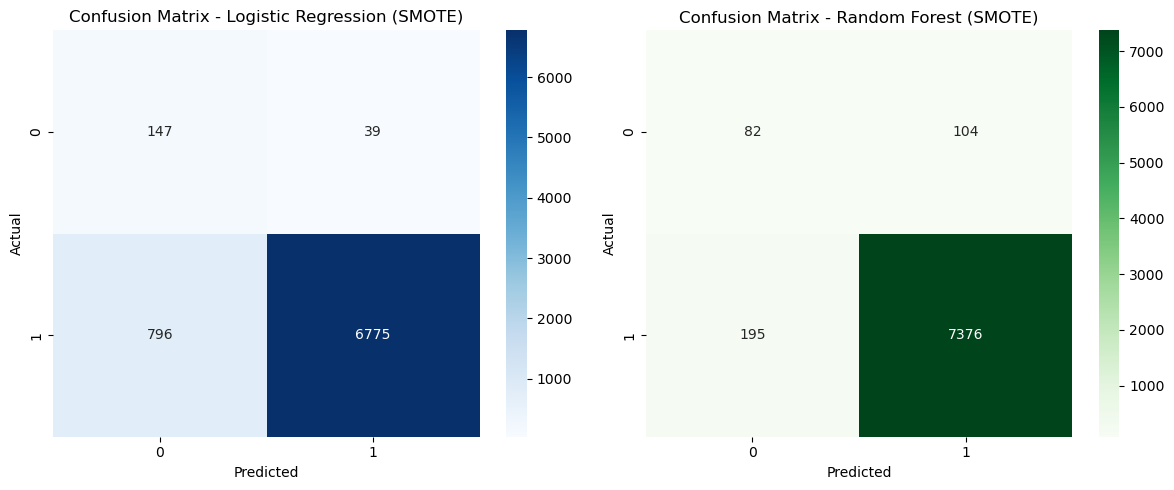

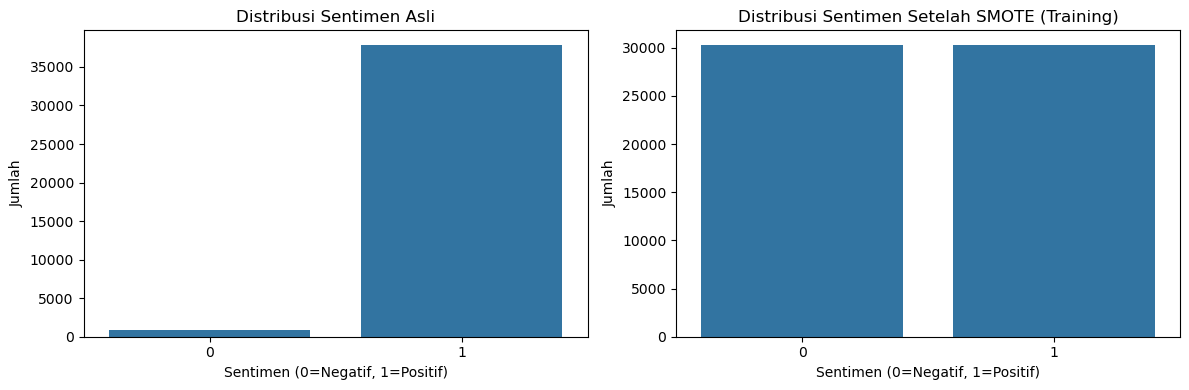

In [34]:
# --------------------------------------------------------------------
# [PERBAIKAN 5] VISUALISASI LEBIH LENGKAP
# --------------------------------------------------------------------

# --- Confusion Matrix untuk Model Terbaik (pilih LR atau RF) ---
# Saya pilih Logistic Regression karena lebih simpel dan interpretatif
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression (SMOTE)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest (SMOTE)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- Distribusi sentimen (sebelum dan sesudah SMOTE) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sebelum SMOTE (Data Asli)
sns.countplot(x='sentiment', data=df, ax=axes[0])
axes[0].set_title('Distribusi Sentimen Asli')
axes[0].set_xlabel('Sentimen (0=Negatif, 1=Positif)')
axes[0].set_ylabel('Jumlah')

# Sesudah SMOTE (Data Training yang sudah di-resample)
sns.countplot(x=y_train_resampled, ax=axes[1])
axes[1].set_title('Distribusi Sentimen Setelah SMOTE (Training)')
axes[1].set_xlabel('Sentimen (0=Negatif, 1=Positif)')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

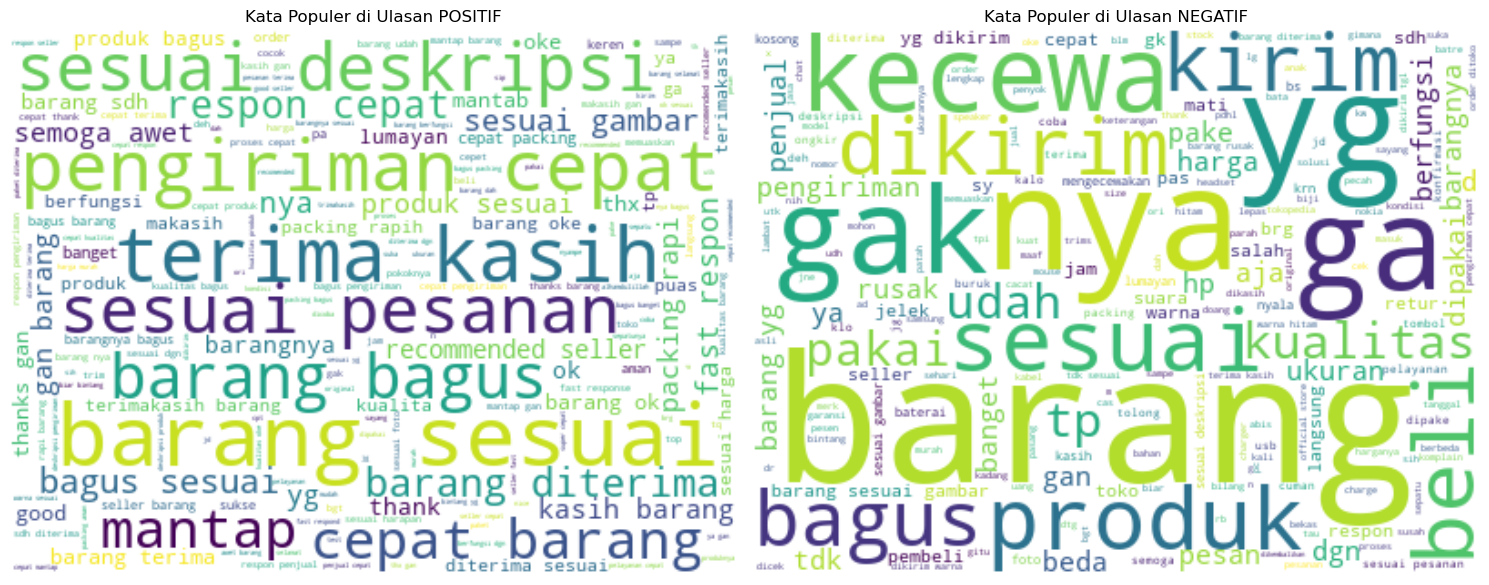

In [35]:
# --- WordCloud POSITIF & NEGATIF (Perbandingan) ---
# Text Positif
pos_text = ' '.join(df[df['sentiment']==1]['clean_review'])
# Text Negatif
neg_text = ' '.join(df[df['sentiment']==0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# WordCloud Positif
wordcloud_pos = WordCloud(width=400, height=300, background_color='white').generate(pos_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Kata Populer di Ulasan POSITIF')
axes[0].axis('off')

# WordCloud Negatif
wordcloud_neg = WordCloud(width=400, height=300, background_color='white').generate(neg_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Kata Populer di Ulasan NEGATIF')
axes[1].axis('off')

plt.tight_layout()
plt.show()